In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.backends.cudnn.benchmark = True

import torch
print(torch.cuda.get_device_name(0))

Using device: cuda
NVIDIA H200


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from tqdm import tqdm

# -----------------------------
# Device
# -----------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Dataset Paths
# -----------------------------

DATA_DIR = "retinal_oct"

train_dir = os.path.join(DATA_DIR, "training/train")
val_dir   = os.path.join(DATA_DIR, "training/val")
test_dir  = os.path.join(DATA_DIR, "test")

# -----------------------------
# Transforms
# -----------------------------

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# -----------------------------
# Load Dataset
# -----------------------------

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# Faster DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

class_names = train_dataset.classes
print("Classes:", class_names)

Using device: cuda
Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [4]:
import torch
import torch.nn as nn

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc(self.avg_pool(x))
        max = self.fc(self.max_pool(x))
        return self.sigmoid(avg + max)

In [5]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        self.conv = nn.Conv2d(
            2, 1, kernel_size=kernel_size,
            padding=kernel_size//2, bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg = torch.mean(x, dim=1, keepdim=True)
        max,_ = torch.max(x, dim=1, keepdim=True)

        x = torch.cat([avg, max], dim=1)

        return self.sigmoid(self.conv(x))

In [6]:
class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):

        x = x * self.ca(x)
        x = x * self.sa(x)

        return x

In [7]:
from torchvision import models

class EfficientNet_CBAM(nn.Module):

    def __init__(self, num_classes=4):
        super().__init__()

        base = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        self.features = base.features
        self.cbam = CBAM(1280)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(1280, num_classes)

    def forward(self, x):

        x = self.features(x)

        x = self.cbam(x)

        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

eff_cbam = EfficientNet_CBAM(num_classes=4).to(device)

print("EfficientNet + CBAM initialized")

EfficientNet + CBAM initialized


In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(eff_cbam.parameters(), lr=1e-4)

In [10]:
from tqdm import tqdm

def train_eff_cbam(model, train_loader, val_loader, epochs=5):

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for imgs, labels in tqdm(train_loader):

            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(imgs)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        print("Epoch:", epoch+1, "Loss:", running_loss)

In [11]:
train_eff_cbam(eff_cbam, train_loader, val_loader, epochs=5)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1916/1916 [07:28<00:00,  4.27it/s]


Epoch: 1 Loss: 438.0828777849674


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1916/1916 [03:51<00:00,  8.27it/s]


Epoch: 2 Loss: 248.33390483167022


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1916/1916 [03:50<00:00,  8.31it/s]


Epoch: 3 Loss: 207.15803966345266


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1916/1916 [06:11<00:00,  5.15it/s]


Epoch: 4 Loss: 176.8019798710011


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1916/1916 [05:35<00:00,  5.70it/s]

Epoch: 5 Loss: 154.91022061533295


In [12]:
eff_cbam.fc = nn.Identity()

eff_cbam.eval()

print("Converted to feature extractor")

Converted to feature extractor


In [13]:
import numpy as np

def extract_features(loader, model):

    features = []
    labels = []

    with torch.no_grad():

        for imgs, lbls in tqdm(loader):

            imgs = imgs.to(device)

            outputs = model(imgs)

            features.append(outputs.cpu().numpy())

            labels.append(lbls.numpy())

    return np.vstack(features), np.hstack(labels)

In [14]:
X_train, y_train = extract_features(train_loader, eff_cbam)

X_test, y_test = extract_features(test_loader, eff_cbam)

print(X_train.shape, X_test.shape)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 240/240 [00:32<00:00,  7.39it/s]

(61284, 1280) (7664, 1280)


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

EfficientNet + CBAM Accuracy: 0.9703810020876826

Classification Report:

              precision    recall  f1-score   support

         CNV       0.98      0.98      0.98      3165
         DME       0.97      0.96      0.97      1099
      DRUSEN       0.92      0.89      0.90       783
      NORMAL       0.97      0.98      0.98      2617

    accuracy                           0.97      7664
   macro avg       0.96      0.96      0.96      7664
weighted avg       0.97      0.97      0.97      7664



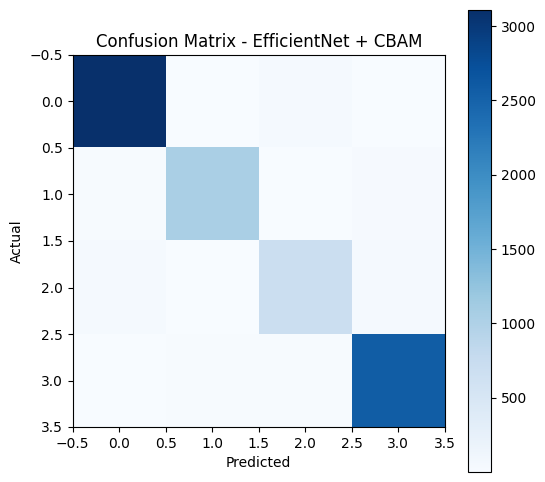

In [16]:
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("EfficientNet + CBAM Accuracy:", acc)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred, target_names=class_names))


from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix - EfficientNet + CBAM")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
### Code along with saving

Using device: cuda
Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
EfficientNet + CBAM initialized


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1916/1916 [04:28<00:00,  7.12it/s]


Epoch: 1 Loss: 471.38887904956937


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1916/1916 [04:25<00:00,  7.22it/s]


Epoch: 2 Loss: 257.00770420674235


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1916/1916 [02:32<00:00, 12.56it/s]


Epoch: 3 Loss: 209.30877458443865


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1916/1916 [02:09<00:00, 14.80it/s]


Epoch: 4 Loss: 178.32223256025463


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1916/1916 [04:04<00:00,  7.83it/s]


Epoch: 5 Loss: 158.86187682137825
✅ CNN model saved
Converted to feature extractor


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 240/240 [00:27<00:00,  8.59it/s]


(61284, 1280) (7664, 1280)
✅ RF model + classes saved
EfficientNet + CBAM Accuracy: 0.9701200417536534

Classification Report:

              precision    recall  f1-score   support

         CNV       0.98      0.98      0.98      3165
         DME       0.97      0.95      0.96      1099
      DRUSEN       0.91      0.90      0.91       783
      NORMAL       0.97      0.98      0.98      2617

    accuracy                           0.97      7664
   macro avg       0.96      0.95      0.96      7664
weighted avg       0.97      0.97      0.97      7664



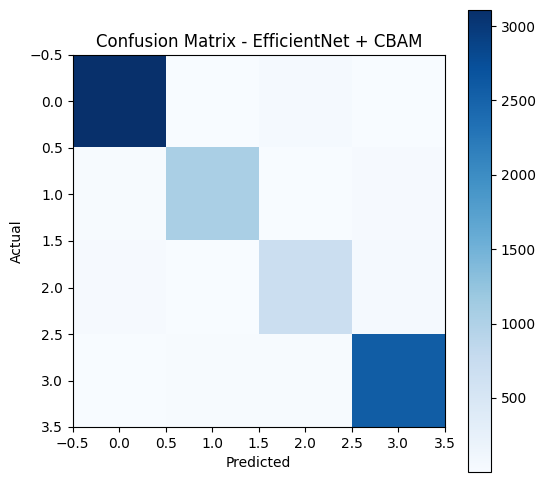

In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from tqdm import tqdm
import joblib
import json



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



DATA_DIR = "retinal_oct"

train_dir = os.path.join(DATA_DIR, "training/train")
val_dir   = os.path.join(DATA_DIR, "training/val")
test_dir  = os.path.join(DATA_DIR, "test")



train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])




train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

class_names = train_dataset.classes
print("Classes:", class_names)



class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc(self.avg_pool(x))
        max = self.fc(self.max_pool(x))
        return self.sigmoid(avg + max)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max,_ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg, max], dim=1)
        return self.sigmoid(self.conv(x))

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class EfficientNet_CBAM(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.features = base.features
        self.cbam = CBAM(1280)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x



eff_cbam = EfficientNet_CBAM(num_classes=4).to(device)
print("EfficientNet + CBAM initialized")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(eff_cbam.parameters(), lr=1e-4)

def train_eff_cbam(model, train_loader, val_loader, epochs=5):
    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for imgs, labels in tqdm(train_loader):
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print("Epoch:", epoch+1, "Loss:", running_loss)

train_eff_cbam(eff_cbam, train_loader, val_loader, epochs=5)

# ============================
# ===== ADDED: SAVE CNN ======
# ============================

torch.save(eff_cbam.state_dict(), "MyProject_effcbam_model.pth")
print("✅ CNN model saved")



eff_cbam.fc = nn.Identity()
eff_cbam.eval()

print("Converted to feature extractor")

def extract_features(loader, model):
    features, labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader):
            imgs = imgs.to(device)
            outputs = model(imgs)
            features.append(outputs.cpu().numpy())
            labels.append(lbls.numpy())
    return np.vstack(features), np.hstack(labels)

X_train, y_train = extract_features(train_loader, eff_cbam)
X_test, y_test   = extract_features(test_loader, eff_cbam)

print(X_train.shape, X_test.shape)



rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# ============================
# ===== ADDED: SAVE RF =======
# ============================

joblib.dump(rf, "MyProject_rf_model.pkl")

with open("MyProject_classes.json", "w") as f:
    json.dump(class_names, f)

print("✅ RF model + classes saved")



acc = accuracy_score(y_test, y_pred)
print("EfficientNet + CBAM Accuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - EfficientNet + CBAM")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()